In [1]:
import numpy as np
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import glob

actions = [
    'come',
    'away',
    'spin',
    'wave',
    'heart',
    'sleep'
]

# dataset 폴더에서 각 action 에 해당하는 seq_*.npy 를 모두 불러와 합친다
# (학습 데이터를 여러 번 수집했어도 전부 사용하도록 glob 사용)
arrays = []
for action in actions:
    files = sorted(glob.glob(os.path.join('dataset', f'seq_{action}_*.npy')))
    if not len(files):
        raise FileNotFoundError(f'dataset/seq_{action}_*.npy 파일이 없습니다. 먼저 250422_create_dataset.py 를 실행해 데이터를 모으세요.')
    for f in files:
        arrays.append(np.load(f))
        print(f'  - loaded {f}  shape={arrays[-1].shape}')

data = np.concatenate(arrays, axis=0)
data.shape

  - loaded dataset\seq_come_1776844963.npy  shape=(796, 30, 100)
  - loaded dataset\seq_away_1776844963.npy  shape=(860, 30, 100)
  - loaded dataset\seq_spin_1776844963.npy  shape=(842, 30, 100)
  - loaded dataset\seq_wave_1776844963.npy  shape=(854, 30, 100)
  - loaded dataset\seq_heart_1776844963.npy  shape=(855, 30, 100)
  - loaded dataset\seq_sleep_1776844963.npy  shape=(863, 30, 100)


(5070, 30, 100)

In [3]:
x_data = data[:, :, :-1]
labels = data[:, 0, -1]

print(x_data.shape)
print(labels.shape)

(5070, 30, 99)
(5070,)


In [4]:
from keras.utils import to_categorical

y_data = to_categorical(labels, num_classes=len(actions))
y_data.shape

(5070, 6)

In [5]:
from sklearn.model_selection import train_test_split

x_data = x_data.astype(np.float32)
y_data = y_data.astype(np.float32)

x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=2026)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(4056, 30, 99) (4056, 6)
(1014, 30, 99) (1014, 6)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=x_train.shape[1:3]),
    Dense(32, activation='relu'),
    Dense(len(actions), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                41984     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 6)                 198       
                                                                 
Total params: 44262 (172.90 KB)
Trainable params: 44262 (172.90 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

os.makedirs('models', exist_ok=True)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=200,
    callbacks=[
        ModelCheckpoint('models/250422_model.h5', monitor='val_acc', verbose=2, save_best_only=True, mode='auto'),
        ReduceLROnPlateau(monitor='val_acc', factor=0.5, patience=50, verbose=2, mode='auto')
    ]
)

model.save('models/250422_model.h5')

Epoch 1/200


125/127 [============================>.] - ETA: 0s - loss: 0.6184 - acc: 0.8497
Epoch 1: val_acc improved from -inf to 0.97337, saving model to models\250422_model.h5
127/127 [==============================] - 5s 20ms/step - loss: 0.6119 - acc: 0.8516 - val_loss: 0.1212 - val_acc: 0.9734 - lr: 0.0010
Epoch 2/200
  9/127 [=>............................] - ETA: 1s - loss: 0.0836 - acc: 0.9792

c:\Users\user\anaconda3\envs\finger\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


126/127 [============================>.] - ETA: 0s - loss: 0.0535 - acc: 0.9886
Epoch 2: val_acc improved from 0.97337 to 0.99507, saving model to models\250422_model.h5
127/127 [==============================] - 2s 15ms/step - loss: 0.0532 - acc: 0.9887 - val_loss: 0.0308 - val_acc: 0.9951 - lr: 0.0010
Epoch 3/200
127/127 [==============================] - ETA: 0s - loss: 0.0195 - acc: 0.9965
Epoch 3: val_acc improved from 0.99507 to 0.99803, saving model to models\250422_model.h5
127/127 [==============================] - 2s 15ms/step - loss: 0.0195 - acc: 0.9965 - val_loss: 0.0169 - val_acc: 0.9980 - lr: 0.0010
Epoch 4/200
124/127 [============================>.] - ETA: 0s - loss: 0.0073 - acc: 0.9992
Epoch 4: val_acc improved from 0.99803 to 1.00000, saving model to models\250422_model.h5
127/127 [==============================] - 2s 15ms/step - loss: 0.0072 - acc: 0.9993 - val_loss: 0.0043 - val_acc: 1.0000 - lr: 0.0010
Epoch 5/200
124/127 [============================>.] - ETA: 0

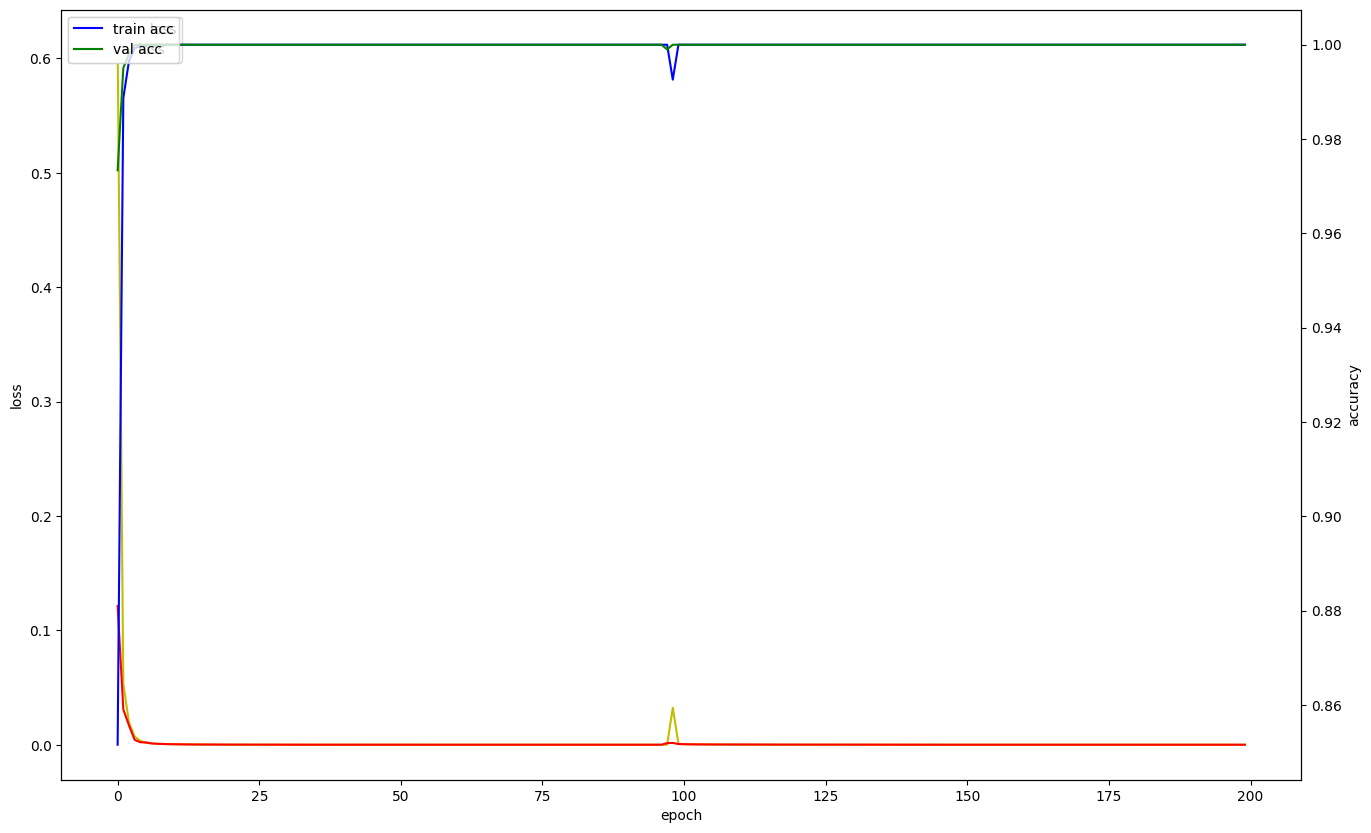

In [8]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots(figsize=(16, 10))
acc_ax = loss_ax.twinx()

loss_ax.plot(history.history['loss'], 'y', label='train loss')
loss_ax.plot(history.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper left')

acc_ax.plot(history.history['acc'], 'b', label='train acc')
acc_ax.plot(history.history['val_acc'], 'g', label='val acc')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc='upper left')

plt.show()

In [9]:
from sklearn.metrics import multilabel_confusion_matrix
from tensorflow.keras.models import load_model

model = load_model('models/250422_model.h5')

y_pred = model.predict(x_val)

multilabel_confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))

32/32 [==============================] - 1s 7ms/step


array([[[846,   0],
        [  0, 168]],

       [[863,   0],
        [  0, 151]],

       [[854,   0],
        [  0, 160]],

       [[830,   0],
        [  0, 184]],

       [[832,   0],
        [  0, 182]],

       [[845,   0],
        [  0, 169]]], dtype=int64)